# Question Clustering Pipeline

Lean pipeline for clustering questions and determining optimal resolution per cluster.

In [ ]:
import json
import re
import pickle
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import friedmanchisquare
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE
from sentence_transformers import SentenceTransformer
import nltk
from nltk.corpus import stopwords

# Ensure NLTK data
for res in ['punkt', 'punkt_tab', 'averaged_perceptron_tagger', 'averaged_perceptron_tagger_eng', 'stopwords']:
    try: nltk.data.find(f'tokenizers/{res}' if 'punkt' in res else f'corpora/{res}' if res == 'stopwords' else f'taggers/{res}')
    except LookupError: nltk.download(res, quiet=True)

sns.set_style("whitegrid")
%matplotlib inline

In [ ]:
# =============================================================================
# CONFIGURATION
# =============================================================================

# Dataset paths
TRAINING_DATASET = '../../benchmarks/seedbench_2_plus/test_questions.jsonl'
VALIDATION_DATASET = None  # Set path for validation dataset if available
SCORES_FILE = '../../benchmarks/seedbench_2_plus/seedbench_2_plus_resolution_analysis.xlsx'
SCORES_SHEET = 'Consolidated_Scores'

# Clustering parameters
MIN_K = 5
MAX_K = 30
RANDOM_STATE = 42

# Resolutions to analyze
RESOLUTIONS = ['2000', '12500', '25000', '50000', '100000', '150000', '250000', '400000', '600000', '800000']

# Embedding model
EMBEDDING_MODEL = 'all-MiniLM-L6-v2'

# Output paths
MODEL_OUTPUT = 'artifacts/clustering_model.pkl'
MAPPING_OUTPUT = 'results/cluster_resolution_mapping.csv'

## 3. Clustering

In [7]:
print("Loading sentence transformer model...")
model = SentenceTransformer('all-MiniLM-L6-v2')

print("Generating embeddings...")
embeddings = model.encode(df['question_stem'].tolist(), show_progress_bar=True)
print(f"Embeddings shape: {embeddings.shape}")

Loading sentence transformer model...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 553.79it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Generating embeddings...


Batches: 100%|██████████| 72/72 [00:07<00:00,  9.17it/s]

Embeddings shape: (2277, 384)


Finding optimal K...


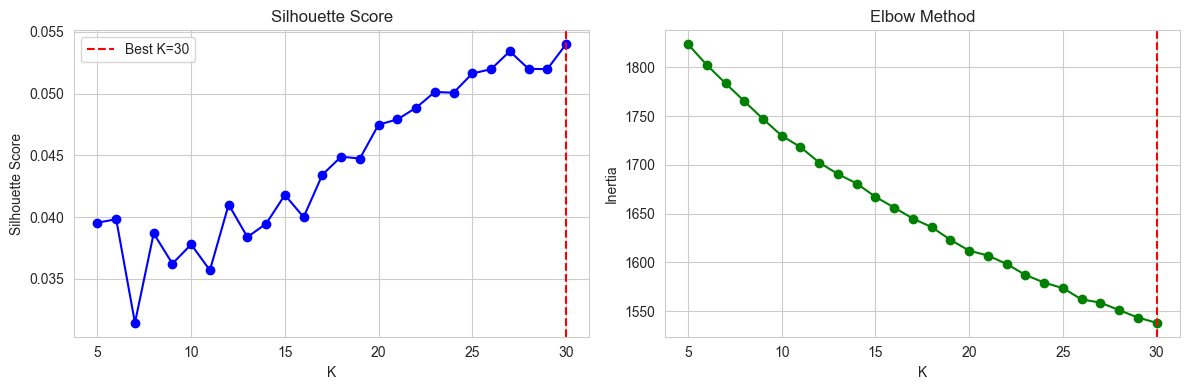


Optimal K: 30


In [8]:
# K Selection
k_range = range(MIN_K, MAX_K + 1)
silhouette_scores = []
inertias = []

print("Finding optimal K...")
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = kmeans.fit_predict(embeddings)
    silhouette_scores.append(silhouette_score(embeddings, labels))
    inertias.append(kmeans.inertia_)

OPTIMAL_K = k_range[np.argmax(silhouette_scores)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(k_range, silhouette_scores, 'bo-')
ax1.axvline(OPTIMAL_K, color='red', linestyle='--', label=f'Best K={OPTIMAL_K}')
ax1.set_xlabel('K'); ax1.set_ylabel('Silhouette Score'); ax1.set_title('Silhouette Score'); ax1.legend()

ax2.plot(k_range, inertias, 'go-')
ax2.axvline(OPTIMAL_K, color='red', linestyle='--')
ax2.set_xlabel('K'); ax2.set_ylabel('Inertia'); ax2.set_title('Elbow Method')

plt.tight_layout()
plt.show()
print(f"\nOptimal K: {OPTIMAL_K}")

In [9]:
# Train final model and save
kmeans_final = KMeans(n_clusters=OPTIMAL_K, random_state=RANDOM_STATE, n_init=10)
df['cluster'] = kmeans_final.fit_predict(embeddings)

# Save model
with open(MODEL_OUTPUT, 'wb') as f:
    pickle.dump({'kmeans': kmeans_final, 'embedding_model': EMBEDDING_MODEL, 'optimal_k': OPTIMAL_K}, f)

print(f"Model saved to {MODEL_OUTPUT}")
print(f"\nCluster distribution:")
print(df['cluster'].value_counts().sort_index())

Model saved to clustering_model.pkl

Cluster distribution:
cluster
0      19
1      47
2      41
3      79
4      88
5     113
6     101
7     152
8     139
9      58
10     61
11     35
12    122
13     57
14     52
15     26
16     82
17     34
18     79
19     72
20    127
21     91
22     93
23     64
24     28
25    144
26     35
27     98
28     60
29     80
Name: count, dtype: int64


Running t-SNE...


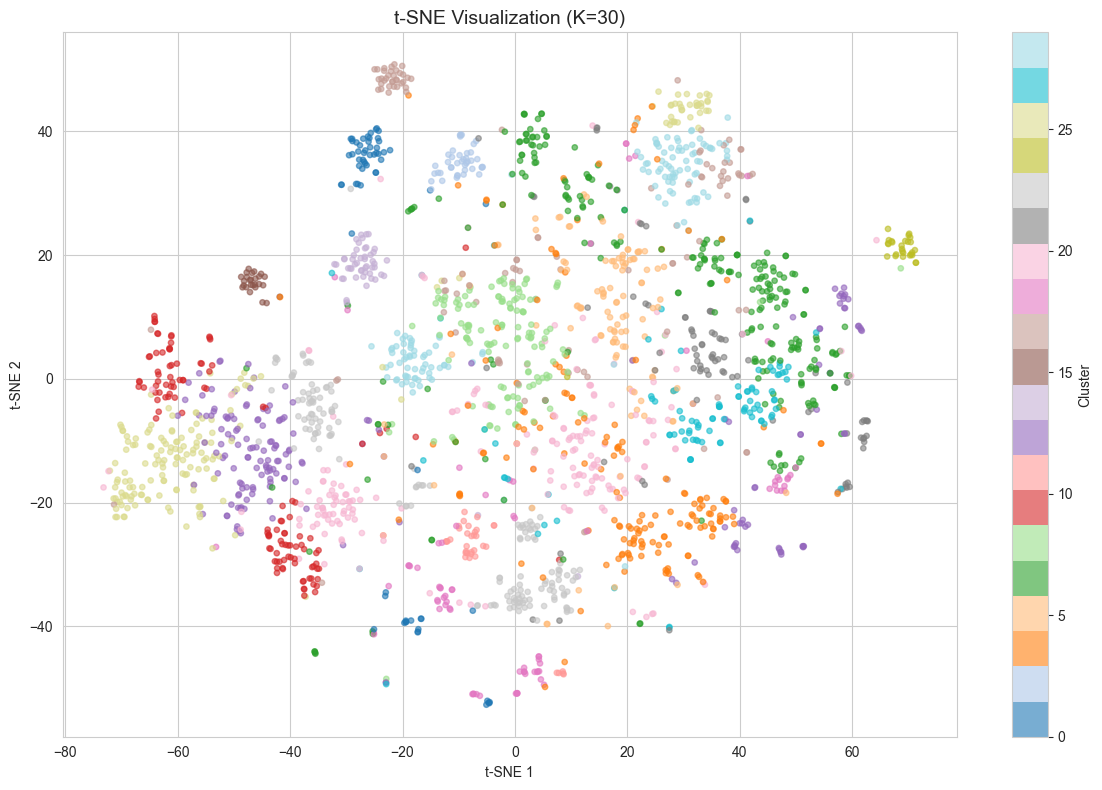

In [10]:
# t-SNE Visualization
print("Running t-SNE...")
tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30, init='pca', learning_rate='auto')
tsne_coords = tsne.fit_transform(embeddings)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(tsne_coords[:, 0], tsne_coords[:, 1], c=df['cluster'], cmap='tab20', alpha=0.6, s=15)
plt.colorbar(scatter, label='Cluster')
plt.title(f't-SNE Visualization (K={OPTIMAL_K})', fontsize=14)
plt.xlabel('t-SNE 1'); plt.ylabel('t-SNE 2')
plt.tight_layout()
plt.show()

## 4. Resolution Analysis

In [11]:
# Compute accuracy per cluster per resolution
cluster_perf = []
for cluster_id in sorted(df['cluster'].unique()):
    subset = df[df['cluster'] == cluster_id]
    row = {'cluster': cluster_id, 'n_questions': len(subset)}
    for res in RESOLUTIONS:
        row[f'acc_{res}'] = subset[res].mean()
    cluster_perf.append(row)

df_cluster = pd.DataFrame(cluster_perf).set_index('cluster')

# Compute summary stats
acc_cols = [f'acc_{r}' for r in RESOLUTIONS]
df_cluster['mean_acc'] = df_cluster[acc_cols].mean(axis=1)
df_cluster['std_acc'] = df_cluster[acc_cols].std(axis=1)
df_cluster['min_acc'] = df_cluster[acc_cols].min(axis=1)
df_cluster['max_acc'] = df_cluster[acc_cols].max(axis=1)
df_cluster['range_acc'] = df_cluster['max_acc'] - df_cluster['min_acc']
df_cluster['best_resolution'] = df_cluster[acc_cols].idxmax(axis=1).str.replace('acc_', '')
df_cluster['worst_resolution'] = df_cluster[acc_cols].idxmin(axis=1).str.replace('acc_', '')

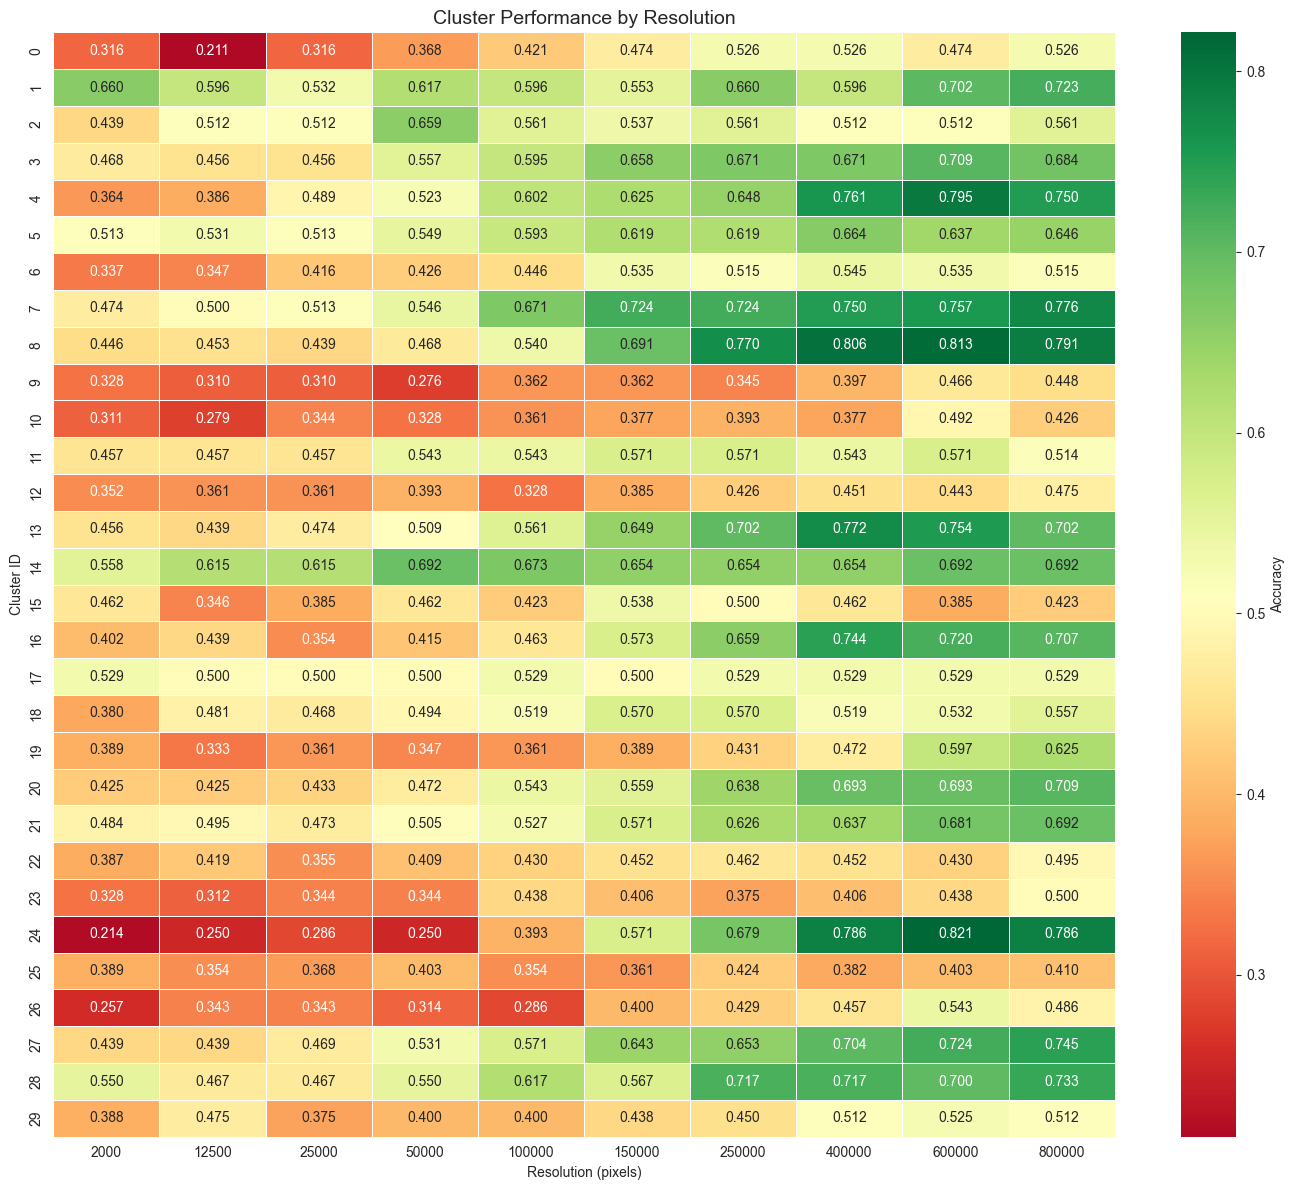

In [12]:
# Cluster Performance by Resolution - Heatmap
heatmap_data = df_cluster[acc_cols].copy()
heatmap_data.columns = RESOLUTIONS

plt.figure(figsize=(14, max(8, OPTIMAL_K * 0.4)))
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='RdYlGn', 
            center=heatmap_data.values.mean(), linewidths=0.5, cbar_kws={'label': 'Accuracy'})
plt.title('Cluster Performance by Resolution', fontsize=14)
plt.xlabel('Resolution (pixels)'); plt.ylabel('Cluster ID')
plt.tight_layout()
plt.show()

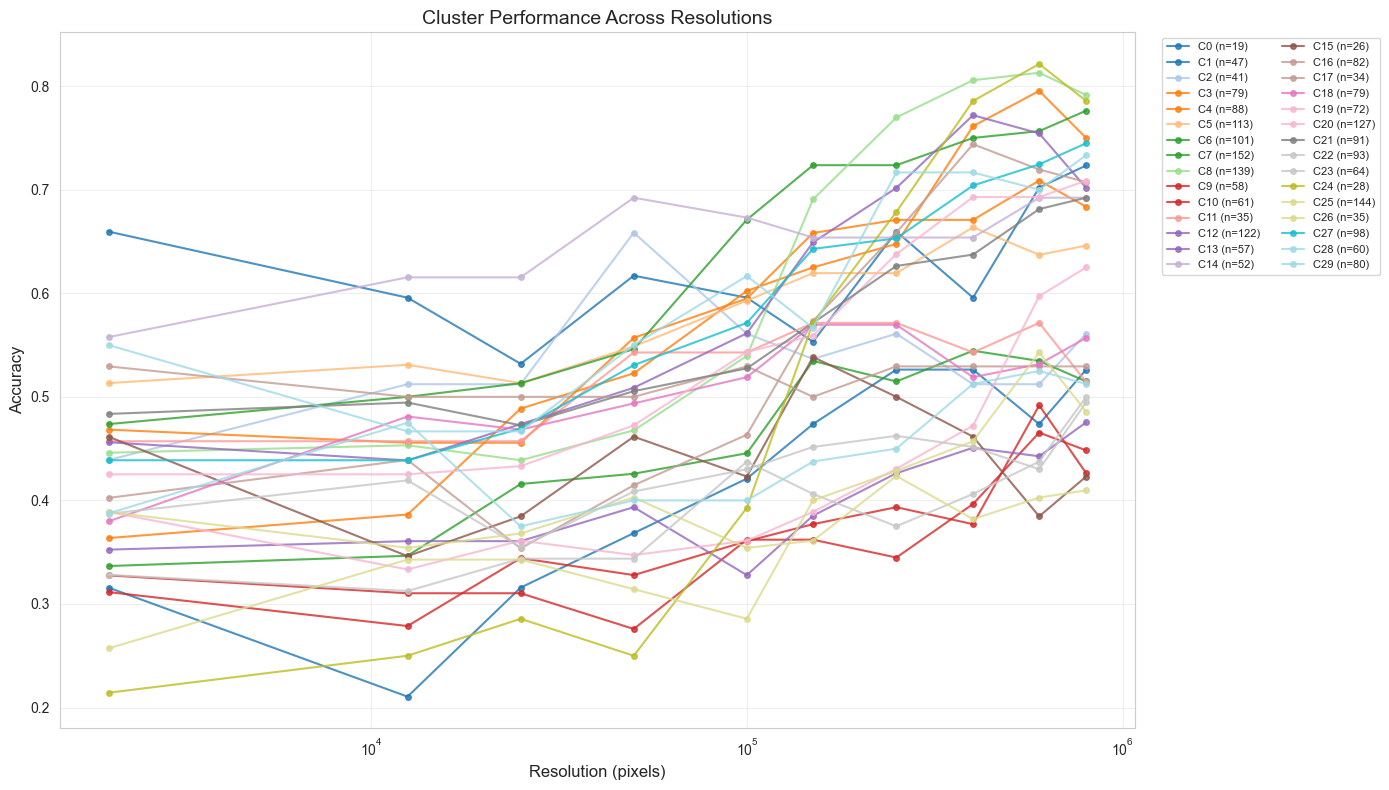

In [13]:
# Cluster Performance Across Resolutions - Line Plot
plt.figure(figsize=(14, 8))
resolutions_int = [int(r) for r in RESOLUTIONS]
colors = plt.cm.tab20(np.linspace(0, 1, OPTIMAL_K))

for cluster_id in sorted(df['cluster'].unique()):
    accuracies = [df_cluster.loc[cluster_id, f'acc_{r}'] for r in RESOLUTIONS]
    n = df_cluster.loc[cluster_id, 'n_questions']
    plt.plot(resolutions_int, accuracies, 'o-', color=colors[cluster_id], 
             label=f'C{cluster_id} (n={n})', linewidth=1.5, markersize=4, alpha=0.8)

plt.xlabel('Resolution (pixels)', fontsize=12); plt.ylabel('Accuracy', fontsize=12)
plt.title('Cluster Performance Across Resolutions', fontsize=14)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8, ncol=2)
plt.xscale('log'); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
# Cluster Resolution Sensitivity Analysis Table
sensitivity_table = df_cluster[['n_questions', 'mean_acc', 'std_acc', 'min_acc', 'max_acc', 
                                 'range_acc', 'best_resolution', 'worst_resolution']].copy()

print("=" * 100)
print("CLUSTER RESOLUTION SENSITIVITY ANALYSIS")
print("=" * 100)
display(sensitivity_table.round(4))

CLUSTER RESOLUTION SENSITIVITY ANALYSIS


,n_questions,mean_acc,std_acc,min_acc,max_acc,range_acc,best_resolution,worst_resolution
cluster,,,,,,,,
0,19,0.4158,0.1094,0.2105,0.5263,0.3158,250000,12500
1,47,0.6234,0.0619,0.5319,0.7234,0.1915,800000,25000
2,41,0.5366,0.0563,0.4390,0.6585,0.2195,50000,2000
3,79,0.5924,0.1014,0.4557,0.7089,0.2532,600000,12500
4,88,0.5943,0.1525,0.3636,0.7955,0.4318,600000,2000
5,113,0.5885,0.0572,0.5133,0.6637,0.1504,400000,2000
6,101,0.4614,0.0787,0.3366,0.5446,0.2079,400000,2000
7,152,0.6434,0.1208,0.4737,0.7763,0.3026,800000,2000
8,139,0.6216,0.1664,0.4388,0.8129,0.3741,600000,25000


In [15]:
# Generate resolution mapping with efficient resolution
mapping = []
for cluster_id in sorted(df['cluster'].unique()):
    row = df_cluster.loc[cluster_id]
    acc_at_res = {res: row[f'acc_{res}'] for res in RESOLUTIONS}
    
    best_res = max(acc_at_res, key=acc_at_res.get)
    best_acc = acc_at_res[best_res]
    
    # Efficient resolution (95% of best)
    threshold = best_acc * 0.95
    efficient_res = best_res
    for res in RESOLUTIONS:
        if acc_at_res[res] >= threshold:
            efficient_res = res
            break
    
    mapping.append({
        'cluster': cluster_id,
        'n_questions': row['n_questions'],
        'best_resolution': best_res,
        'best_accuracy': best_acc,
        'efficient_res_95pct': efficient_res,
        'acc_at_efficient': acc_at_res[efficient_res]
    })

df_mapping = pd.DataFrame(mapping)
df_mapping.to_csv(MAPPING_OUTPUT, index=False)

print(f"\nResolution mapping saved to {MAPPING_OUTPUT}")
print("\nFINAL CLUSTER RESOLUTION MAPPING:")
display(df_mapping.round(4))


Resolution mapping saved to cluster_resolution_mapping.csv

FINAL CLUSTER RESOLUTION MAPPING:


,cluster,n_questions,best_resolution,best_accuracy,efficient_res_95pct,acc_at_efficient
0,0,19,250000,0.5263,250000,0.5263
1,1,47,800000,0.7234,600000,0.7021
2,2,41,50000,0.6585,50000,0.6585
3,3,79,600000,0.7089,600000,0.7089
4,4,88,600000,0.7955,400000,0.7614
5,5,113,400000,0.6637,400000,0.6637
6,6,101,400000,0.5446,150000,0.5347
7,7,152,800000,0.7763,400000,0.7500
8,8,139,600000,0.8129,400000,0.8058
9,9,58,600000,0.4655,600000,0.4655


In [16]:
# Summary Statistics
print("=" * 80)
print("SUMMARY")
print("=" * 80)
print(f"\nTotal questions: {len(df)}")
print(f"Number of clusters: {OPTIMAL_K}")
print(f"Cluster size range: {df_cluster['n_questions'].min()} - {df_cluster['n_questions'].max()}")
print(f"\nOverall accuracy at max resolution ({RESOLUTIONS[-1]}): {df[RESOLUTIONS[-1]].mean():.4f}")
print(f"Most resolution-sensitive cluster: {df_cluster['range_acc'].idxmax()} (range={df_cluster['range_acc'].max():.4f})")
print(f"Most resolution-stable cluster: {df_cluster['range_acc'].idxmin()} (range={df_cluster['range_acc'].min():.4f})")

# Resolution distribution
print(f"\nBest Resolution Distribution:")
for res in RESOLUTIONS:
    count = (df_mapping['best_resolution'] == res).sum()
    if count > 0:
        questions = df_mapping[df_mapping['best_resolution'] == res]['n_questions'].sum()
        print(f"  {res}: {count} clusters ({questions} questions)")

SUMMARY

Total questions: 2277
Number of clusters: 30
Cluster size range: 19 - 152

Overall accuracy at max resolution (800000): 0.6179
Most resolution-sensitive cluster: 24 (range=0.6071)
Most resolution-stable cluster: 17 (range=0.0294)

Best Resolution Distribution:
  2000: 1 clusters (34 questions)
  50000: 2 clusters (93 questions)
  150000: 3 clusters (140 questions)
  250000: 2 clusters (163 questions)
  400000: 4 clusters (353 questions)
  600000: 8 clusters (568 questions)
  800000: 10 clusters (926 questions)


## 5. Clusters x Resolutions: Statistical Analysis

In [ ]:
# ACCURACY BY CLUSTER AND RESOLUTION - Heatmap (ordered by cluster ID)
heatmap_acc = df_cluster[acc_cols].copy()
heatmap_acc.columns = RESOLUTIONS

plt.figure(figsize=(14, max(8, OPTIMAL_K * 0.4)))
sns.heatmap(heatmap_acc, annot=True, fmt='.3f', cmap='RdYlGn',
            center=heatmap_acc.values.mean(), linewidths=0.5, cbar_kws={'label': 'Accuracy'})
plt.title('ACCURACY BY CLUSTER AND RESOLUTION', fontsize=14)
plt.xlabel('Resolution (pixels)'); plt.ylabel('Cluster ID')
plt.tight_layout()
plt.show()

In [ ]:
# Statistical Test Results by Cluster (Friedman Test)
stat_results = []
for cluster_id in sorted(df['cluster'].unique()):
    subset = df[df['cluster'] == cluster_id]
    scores = subset[RESOLUTIONS].values

    try:
        stat, p_val = friedmanchisquare(*[scores[:, i] for i in range(len(RESOLUTIONS))])
    except:
        stat, p_val = np.nan, np.nan

    stat_results.append({
        'cluster': cluster_id,
        'n_questions': len(subset),
        'friedman_stat': stat,
        'p_value': p_val,
        'significant (p<0.05)': p_val < 0.05 if not np.isnan(p_val) else False,
        'best_resolution': df_cluster.loc[cluster_id, 'best_resolution'],
        'best_accuracy': df_cluster.loc[cluster_id, 'max_acc'],
        'range_acc': df_cluster.loc[cluster_id, 'range_acc']
    })

df_friedman = pd.DataFrame(stat_results).sort_values('cluster').reset_index(drop=True)

sig_count = df_friedman['significant (p<0.05)'].sum()
print("=" * 100)
print("STATISTICAL TEST RESULTS BY CLUSTER (Friedman Test)")
print("=" * 100)
print(f"\nClusters where resolution significantly affects accuracy: {sig_count} / {OPTIMAL_K}")
print(f"Clusters where resolution does NOT significantly matter:  {OPTIMAL_K - sig_count} / {OPTIMAL_K}\n")
display(df_friedman.round(4))

## 6. Resolution Recommendations by Cluster

In [ ]:
# Resolution Recommendations: best, 95pct, 99pct (ordered by cluster ID)
recommendations = []
for cluster_id in sorted(df['cluster'].unique()):
    row = df_cluster.loc[cluster_id]
    acc_at_res = {res: row[f'acc_{res}'] for res in RESOLUTIONS}

    best_res = max(acc_at_res, key=acc_at_res.get)
    best_acc = acc_at_res[best_res]

    # Efficient (95%)
    threshold_95 = best_acc * 0.95
    eff_95 = best_res
    for res in RESOLUTIONS:
        if acc_at_res[res] >= threshold_95:
            eff_95 = res
            break

    # Efficient (99%)
    threshold_99 = best_acc * 0.99
    eff_99 = best_res
    for res in RESOLUTIONS:
        if acc_at_res[res] >= threshold_99:
            eff_99 = res
            break

    recommendations.append({
        'cluster': cluster_id,
        'n_questions': row['n_questions'],
        'best_resolution': best_res,
        'best_accuracy': best_acc,
        'efficient_res_95pct': eff_95,
        'acc_at_95pct': acc_at_res[eff_95],
        'efficient_res_99pct': eff_99,
        'acc_at_99pct': acc_at_res[eff_99],
    })

df_rec = pd.DataFrame(recommendations).sort_values('cluster').reset_index(drop=True)

print("=" * 110)
print("RESOLUTION RECOMMENDATIONS BY CLUSTER")
print("=" * 110)
print("\n- best_resolution:      Resolution with highest accuracy")
print("- efficient_res_95pct:  Lowest resolution achieving >= 95% of best accuracy")
print("- efficient_res_99pct:  Lowest resolution achieving >= 99% of best accuracy\n")
display(df_rec.round(4))

## 7. Accuracy vs Computational Cost Trade-off

In [ ]:
# Compute accuracy and cost for each strategy
RESOLUTION_VALUES = [int(r) for r in RESOLUTIONS]
MAX_RES = max(RESOLUTION_VALUES)
total_questions = df_rec['n_questions'].sum()

def compute_strategy(df_rec, df_cluster, res_col=None, fixed_res=None):
    """Compute weighted accuracy and relative cost for a strategy."""
    total_correct = 0
    total_cost = 0
    for _, row in df_rec.iterrows():
        cid = row['cluster']
        n = row['n_questions']
        res = fixed_res if fixed_res else str(int(row[res_col]))
        acc = df_cluster.loc[cid, f'acc_{res}']
        total_correct += acc * n
        total_cost += n * int(res)
    return total_correct / total_questions, total_cost / (total_questions * MAX_RES) * 100

# Fixed resolution strategies
fixed_results = []
for res in RESOLUTIONS:
    acc, cost = compute_strategy(df_rec, df_cluster, fixed_res=res)
    fixed_results.append({'strategy': f'All at {res}', 'accuracy': acc, 'cost_pct': cost})

# Cluster-based strategies
cluster_strategies = [
    ('Best per Cluster', 'best_resolution'),
    ('Efficient (95%)', 'efficient_res_95pct'),
    ('Efficient (99%)', 'efficient_res_99pct'),
]
cluster_results = []
for name, col in cluster_strategies:
    acc, cost = compute_strategy(df_rec, df_cluster, res_col=col)
    cluster_results.append({'strategy': name, 'accuracy': acc, 'cost_pct': cost})

df_fixed = pd.DataFrame(fixed_results)
df_cluster_strat = pd.DataFrame(cluster_results)
df_all_strat = pd.concat([df_fixed, df_cluster_strat], ignore_index=True)

print("STRATEGY COMPARISON")
print("=" * 60)
display(df_all_strat.round(4))

In [ ]:
# Accuracy vs Computational Cost Trade-off
fig, ax = plt.subplots(figsize=(14, 8))

# Fixed resolution curve
ax.plot(df_fixed['cost_pct'], df_fixed['accuracy'], 'o-', color='#3498db',
        markersize=10, linewidth=2, label='Fixed Resolution', zorder=3)

for _, r in df_fixed.iterrows():
    ax.annotate(r['strategy'].replace('All at ', ''),
                (r['cost_pct'], r['accuracy']),
                textcoords='offset points', xytext=(0, 12), ha='center', fontsize=8, color='#2c3e50')

# Cluster-based strategies with prominent annotations
markers = {'Best per Cluster': ('*', '#2ecc71', 300), 
           'Efficient (95%)': ('D', '#e67e22', 200), 
           'Efficient (99%)': ('s', '#e74c3c', 200)}

for _, r in df_cluster_strat.iterrows():
    marker, color, size = markers[r['strategy']]
    ax.scatter(r['cost_pct'], r['accuracy'], marker=marker, c=color,
               s=size, zorder=5, edgecolors='black', linewidth=1, label=r['strategy'])

    # Annotate with visible (x, y) values
    ax.annotate(
        f"{r['strategy']}\n({r['cost_pct']:.1f}%, {r['accuracy']:.4f})",
        (r['cost_pct'], r['accuracy']),
        textcoords='offset points',
        xytext=(15, -20) if 'Best' in r['strategy'] else (15, 15) if '95' in r['strategy'] else (15, -5),
        fontsize=10, fontweight='bold', color=color,
        arrowprops=dict(arrowstyle='->', color=color, lw=1.5),
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=color, alpha=0.9)
    )

ax.set_xlabel('Relative Computational Cost (%)', fontsize=12)
ax.set_ylabel('Overall Accuracy', fontsize=12)
ax.set_title('Accuracy vs Computational Cost Trade-off', fontsize=14)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()